# 06_07 - co-detection, WITHOUT depth correction

In [ ]:
print("Hello World")

In [1]:
# relocation-proof bootstrap: walk up to the .notebooks_root marker
import os
import sys

_d = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_d, '.notebooks_root')):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('could not locate .notebooks_root above this notebook')
    _d = _p
os.chdir(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)
print('working dir:', os.getcwd())

import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath

import senescence_robustness as sr
importlib.reload(sr)

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.width', 240)

working dir: /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks


In [2]:
# preferred plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 6, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'legend.title_fontsize': 6,
    'legend.labelspacing': 0.1, 'legend.borderpad': 0.3, 'legend.handletextpad': 0.2,
    'figure.titlesize': 6,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'figure.titleweight': 'bold',
    'xtick.major.size': TICK_LEN, 'ytick.major.size': TICK_LEN,
    'xtick.major.pad': TICK_LABEL_PAD, 'ytick.major.pad': TICK_LABEL_PAD,
    'axes.labelpad': AXIS_LABEL_PAD,
})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'
matplotlib.rcParams['mathtext.cal'] = 'Arial:italic'
matplotlib.rcParams['mathtext.sf'] = 'Arial'
matplotlib.rcParams['mathtext.tt'] = 'Arial'

P16_COLOR = '#4c72b0'
P14_COLOR = '#dd8452'
BOTH_COLOR = '#c44e52'
DONOR_PALETTE = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860']

H5AD_DIR = '../pacbio/h5ads'
CSV_DIR = '../csvs'
OUT = CSV_DIR + '/06_36_robustness'
os.makedirs(OUT, exist_ok=True)
OBJ = (H5AD_DIR + '/all_samples_pacbio_recollapsed_raw_counts_ensemblids'
       '_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad')
GENES = (H5AD_DIR + '/all_samples_pacbio_recollapsed_raw_counts_genes'
         '_bc_anndata_preprocessed_xgen_cdkn2a.h5ad')
STATUS_COL = 'xgen_cdkn2a_raw_status'
DEPTH = 'total_counts'

# --- NO DEPTH CORRECTION (see header) -------------------------------------
# n_bins=1 puts every cell in one stratum, turning the stratified estimators
# into plain within-unit comparisons. This flag is the only difference from
# the parent notebook.
DEPTH_CORRECTION = False
# NOTE: obs['total_counts'] is STALE on a _with_isofrac object -- 01_09 drops
# single-isoform genes without recomputing it. Harmless here because n_bins=1
# collapses every cell into one stratum, so the depth values never enter the
# arithmetic. This notebook reads obs only (sr.read_h5ad_obs) and never loads X,
# so the guard below is the fix rather than a recompute.
assert not DEPTH_CORRECTION, (
    "DEPTH='total_counts' is stale on this object. Before enabling depth "
    "correction, load X and use adata.X.sum(axis=1) as the depth.")
N_BINS = 10 if DEPTH_CORRECTION else 1          # library-size strata
MIN_OBSERVED = 3     # a sample needs this many co-detections to be estimable
N_PERM = 1000000     # sign-flip resolution = 1/(N_PERM+1)

# --- ANALYSIS POPULATION -----------------------------------------------------
# The capture was applied to the whole 10x cDNA library, so every cell's
# molecules met the probes. `not_in_pulldown` does not mean "skipped": it means
# the barcode never reached the pulldown library's own called-cell threshold,
# which in a CDKN2A-enriched library is close to saying it carried no CDKN2A.
#
# The Appendix tests the alternative -- that failing the call reflects shallow
# capture rather than absent CDKN2A -- by comparing whole-cell depth between
# not_in_pulldown and measured-negative cells. Measured: Cliff's delta -0.120,
# medians 2,160 vs 2,232. They are comparably deep, so the label carries
# information about CDKN2A, not about depth, and these cells are counted as
# genuine negatives.
#
#   'full_atlas'    all 155,117 cells; not_in_pulldown = CDKN2A-negative
#   'measured_only' the original 8,954; not_in_pulldown = missing data
#
# This RAISES the estimate (1.54x -> ~10x): expected co-detection scales as
# N*p*q, so both marginals fall as the population grows. The old setting was
# the conservative one, not the convenient one.
POPULATION = 'full_atlas'
MATCHED_PAIR_MAX_CELLS = 50000   # cap for the dense null only; see Section 7
final = {}

## 1. The published statistics, and the mechanism that undermines them


In [3]:
obs = sr.read_h5ad_obs(OBJ)
status = obs[STATUS_COL].astype(str)
# The population the ANALYSIS runs on.
_meas_only = (status != 'not_in_pulldown').values
if POPULATION == 'full_atlas':
    measured = np.ones(len(status), dtype=bool)
elif POPULATION == 'measured_only':
    measured = _meas_only.copy()
else:
    raise ValueError("POPULATION must be 'full_atlas' or 'measured_only'")
depth = obs[DEPTH].values
p16v = obs['xgen_p16_raw'].values
p14v = obs['xgen_p14ARF_raw'].values

n_p16_only = int((status == 'p16+').sum())
n_p14_only = int((status == 'p14ARF+').sum())
n_both = int((status == 'Both').sum())
n_pos = n_p16_only + n_p14_only + n_both
n_neither = int(measured.sum()) - n_pos          # follows the population

# The PUBLISHED comparators are recomputed on the population they were
# originally defined over, whatever POPULATION is set to -- otherwise the
# target being argued against moves when the analysis population changes, and
# the OR quoted in the draft would no longer be the OR reproduced here.
n_neither_pub = int(_meas_only.sum()) - n_pos
bt = stats.binomtest(n_both, n_pos, 0.5, alternative='greater')
OR_crude, p_fisher = stats.fisher_exact(
    [[n_both, n_p16_only], [n_p14_only, n_neither_pub]], alternative='greater')
print(f'POPULATION = {POPULATION!r}')
print(f'  cells analysed        : {int(measured.sum()):,}')
print(f'  pulldown-called of them: {int(_meas_only.sum()):,}')
print(f'  counted as negative by absence from the pulldown: '
      f'{int(measured.sum()) - int(_meas_only.sum()):,}')
print(f'cells with an identifiable p16/p14ARF transcript: {n_pos:,}  '
      f'both {n_both:,} ({100 * n_both / n_pos:.1f}%)')
print(f'PUBLISHED  Fisher OR = {OR_crude:,.1f}  binomial (null 0.5) p = {bt.pvalue:.1e}')

# mechanism
x = p16v[measured] > 0
y = p14v[measured] > 0
dep = depth[measured]
dbin = sr.depth_bin(dep, n_bins=N_BINS)
rows = []
for b in np.unique(dbin):
    m = dbin == b
    rows.append({'depth_decile': int(b), 'n_cells': int(m.sum()),
                 'median_depth': float(np.median(dep[m])),
                 'P_p16': float(x[m].mean()), 'P_p14ARF': float(y[m].mean()),
                 'P_both': float((x[m] & y[m]).mean())})
depth_tab = pd.DataFrame(rows)
print()
print(depth_tab.round(4).to_string(index=False))
depth_tab.to_csv(OUT + '/06_07_final_detection_vs_depth.csv', index=False)
final['published_crude_or'] = float(OR_crude)
final['published_both_frac'] = n_both / n_pos
final['n_measured_cells'] = int(measured.sum())
final['population'] = POPULATION
final['n_pulldown_called'] = int(_meas_only.sum())

POPULATION = 'full_atlas'
  cells analysed        : 155,117
  pulldown-called of them: 8,954
  counted as negative by absence from the pulldown: 146,163
cells with an identifiable p16/p14ARF transcript: 3,157  both 2,565 (81.2%)
PUBLISHED  Fisher OR = 1,136.2  binomial (null 0.5) p = 5.1e-291

 depth_decile  n_cells  median_depth  P_p16  P_p14ARF  P_both
            0   155117        2198.0 0.0202    0.0167  0.0165


## 2. Primary analysis: sample-level enrichment over a depth-conditional null


In [4]:
tube_m = obs['tube_id'].astype(str).values[measured]
donor_m = obs['donor'].astype(str).values[measured]

tube_enr = sr.codetection_enrichment_by_unit(x, y, tube_m, dbin,
                                             unit_name='tube_id',
                                             min_observed=MIN_OBSERVED)
_t2d = pd.Series(donor_m, index=pd.Index(tube_m)).groupby(level=0).first()
tube_enr['donor'] = tube_enr['tube_id'].map(_t2d)
ok_t = tube_enr.dropna(subset=['effect']).copy()
tube_enr.to_csv(OUT + '/06_07_final_per_sample.csv', index=False)

flat = sr.dersimonian_laird(tube_enr['effect'].values, tube_enr['se'].values)
nested, per_donor = sr.nested_meta_analysis(
    tube_enr['effect'].values, tube_enr['se'].values, tube_enr['donor'].values)
sf = sr.sign_flip_test(tube_enr['effect'].values, n_perm=N_PERM)
per_donor.to_csv(OUT + '/06_07_final_per_donor.csv', index=False)

print(f'samples estimable: {len(ok_t)} of {len(tube_enr)}   '
      f'above 1x: {int((ok_t.enrichment > 1).sum())}')
print()
print('SAMPLE LEVEL (primary)')
print(f"  enrichment {np.exp(flat['effect']):.2f}x  "
      f"95% CI [{np.exp(flat['ci_low']):.2f}, {np.exp(flat['ci_high']):.2f}]")
print(f"  p {flat['p']:.3e}  (Knapp-Hartung, t_{{k-1}})  <- PRIMARY")
print(f"  I2 {flat['I2']:.1f}%")

_res = sf.get('resolution', float('nan'))
print(f"  sign-flip p {sf['p']:.3e}  "
      f"({'exact' if sf.get('exact') else 'sampled, ' + format(sf.get('n_assignments', 0), ',')})"
      f"  floor {sf['floor']:.1e}")
if (not sf.get('exact')) and sf['p'] <= 1.5 * _res:
    print(f"    *** RESOLUTION-LIMITED: report as p < {_res:.0e}, not p = {sf['p']:.0e}")
    print('        No permutation reached the observed value. Quote the KH p instead.')

print()
print('DONOR LEVEL (nested, k=4)')
print(f"  enrichment {np.exp(nested['effect']):.2f}x  "
      f"95% CI [{np.exp(nested['ci_low']):.2f}, {np.exp(nested['ci_high']):.2f}]")
print(f"  p {nested['p']:.4f}  (one-sample t, df={nested['df']})  <- PRIMARY here")
print(f"  p {nested['signflip_p']:.4f}  (sign-flip; floor {nested['signflip_floor']:.3f})")
if nested['signflip_p'] <= nested['signflip_floor'] + 1e-12:
    print('    at the floor -- the t p is bought entirely with normality; report marginal')
print()
print(per_donor.round(4).to_string(index=False))

# empirical null replaces the assumed 0.5
cc = sr.depth_conditional_codetection(x, y, dep, n_bins=(20 if DEPTH_CORRECTION else 1), n_perm=2000, seed=0)
null_prop = cc['expected_perm_mean'] / n_pos
bt2 = stats.binomtest(n_both, n_pos, null_prop, alternative='greater')
print()
print(f'binomial null: assumed 0.500 -> EMPIRICAL {null_prop:.3f}')
print(f'  {n_both}/{n_pos} = {n_both / n_pos:.3f}, p = {bt2.pvalue:.2e} '
      '(still cell-level; quote the sample-level result above instead)')

for k, v in [('sample_enrichment', float(np.exp(flat['effect']))),
             ('sample_ci_low', float(np.exp(flat['ci_low']))),
             ('sample_ci_high', float(np.exp(flat['ci_high']))),
             ('sample_p_kh', flat['p']), ('sample_p_signflip', sf['p']),
             ('sample_I2', flat['I2']), ('n_samples', len(ok_t)),
             ('n_samples_above_1x', int((ok_t.enrichment > 1).sum())),
             ('donor_enrichment', float(np.exp(nested['effect']))),
             ('donor_ci_low', float(np.exp(nested['ci_low']))),
             ('donor_ci_high', float(np.exp(nested['ci_high']))),
             ('donor_p_t', nested['p']), ('empirical_null_both_frac', null_prop),
             ('cell_level_enrichment', cc['enrichment'])]:
    final[k] = v

samples estimable: 39 of 50   above 1x: 39

SAMPLE LEVEL (primary)
  enrichment 28.61x  95% CI [15.96, 51.28]
  p 4.322e-14  (Knapp-Hartung, t_{k-1})  <- PRIMARY
  I2 72.1%
  sign-flip p 1.000e-06  (sampled, 1,000,000)  floor 3.6e-12
    *** RESOLUTION-LIMITED: report as p < 1e-06, not p = 1e-06
        No permutation reached the observed value. Quote the KH p instead.

DONOR LEVEL (nested, k=4)
  enrichment 21.24x  95% CI [12.50, 36.09]
  p 0.0004  (one-sample t, df=3)  <- PRIMARY here
  p 0.1250  (sign-flip; floor 0.125)
    at the floor -- the t p is bought entirely with normality; report marginal

parent  n_units  effect     se  I2_within
 TSP21        8  3.4349 0.4298     0.0000
 TSP25        8  2.6319 0.6074    64.7850
 TSP27       11  3.1433 0.2370     4.5153
 TSP33       12  3.0136 0.3662    19.4553

binomial null: assumed 0.500 -> EMPIRICAL 0.017
  2565/3157 = 0.812, p = 0.00e+00 (still cell-level; quote the sample-level result above instead)


## 3. Why the odds ratio is not reportable


In [5]:
rows = []
for flavour in ['raw', 'umi']:
    p16c = obs['xgen_p16_' + flavour].values[measured]
    p14c = obs['xgen_p14ARF_' + flavour].values[measured]
    other = obs['xgen_other_cdkn2a_' + flavour].values[measured]
    for thr in (1, 2, 3):
        xx, yy = p16c >= thr, p14c >= thr
        a = int((xx & yy).sum()); b = int((xx & ~yy).sum())
        c_ = int((~xx & yy).sum()); d = int((~xx & ~yy).sum())
        crude = (a * d) / (b * c_) if b * c_ > 0 else np.inf
        row = {'flavour': flavour, 'threshold': thr, 'n_both': a, 'crude_OR': crude,
               'MH_wholecell': sr.mantel_haenszel_or(xx, yy, sr.depth_bin(dep, N_BINS))['mh_or']}
        row['MH_pulldown_proxy'] = (np.nan if np.all(other == 0) else
                                    sr.mantel_haenszel_or(xx, yy, sr.depth_bin(other, N_BINS))['mh_or'])
        td = np.array([t + '|' + str(b_) for t, b_ in zip(tube_m, sr.depth_bin(dep, N_BINS))])
        row['MH_tube_x_depth'] = sr.mantel_haenszel_or(xx, yy, td)['mh_or']
        rows.append(row)
or_tab = pd.DataFrame(rows)
or_tab.to_csv(OUT + '/06_07_final_or_instability.csv', index=False)
print(or_tab.round(1).to_string(index=False))
print()
print(f'crude OR range: {or_tab.crude_OR.min():,.0f} to {or_tab.crude_OR.max():,.0f} '
      f'({or_tab.crude_OR.max() / or_tab.crude_OR.min():.1f}x swing across thresholds)')
print('NOTE raw and umi coincide at threshold 1 by construction: groupdedup')
print('over-splitting inflates counts but cannot create a UMI from nothing.')

# degeneracy
deg = []
for t in sorted(set(tube_m)):
    m = tube_m == t
    a = int((x[m] & y[m]).sum()); b = int((x[m] & ~y[m]).sum()); c_ = int((~x[m] & y[m]).sum())
    if a + b + c_ >= 10:
        deg.append({'tube_id': t, 'both': a, 'p16_only': b, 'p14ARF_only': c_,
                    'OR_defined': bool(b > 0 and c_ > 0)})
deg = pd.DataFrame(deg)
n_undef = int((~deg.OR_defined).sum())
print()
print(f'samples where a per-sample OR is UNDEFINED: {n_undef} of {len(deg)} '
      f'({100 * n_undef / len(deg):.0f}%)')
print(f'  p14ARF-only == 0 in {int((deg.p14ARF_only == 0).sum())} of {len(deg)} samples')
deg.to_csv(OUT + '/06_07_final_or_degeneracy.csv', index=False)
final['or_swing'] = float(or_tab.crude_OR.max() / or_tab.crude_OR.min())
final['or_undefined_samples'] = n_undef
final['or_n_samples_checked'] = len(deg)
final['mh_tube_x_depth'] = float(or_tab.loc[(or_tab.flavour == 'raw') &
                                            (or_tab.threshold == 1), 'MH_tube_x_depth'].iloc[0])

flavour  threshold  n_both  crude_OR  MH_wholecell  MH_pulldown_proxy  MH_tube_x_depth
    raw          1    2565   29783.6       29783.6            29783.6           2511.3
    raw          2    2192   25443.2       25443.2            25443.2           1826.6
    raw          3    1895   11571.5       11571.5            11571.5            811.0
    umi          1    2565   29783.6       29783.6            29783.6           2511.3
    umi          2    1213    3497.0        3497.0             3497.0            647.3
    umi          3     610    4778.1        4778.1             4778.1            968.9

crude OR range: 3,497 to 29,784 (8.5x swing across thresholds)
NOTE raw and umi coincide at threshold 1 by construction: groupdedup
over-splitting inflates counts but cannot create a UMI from nothing.

samples where a per-sample OR is UNDEFINED: 21 of 28 (75%)
  p14ARF-only == 0 in 21 of 28 samples


## 4. Sensitivity to the two free parameters


In [6]:
rows = []
# nothing to sweep with a single bin
for nb_ in ((5, 10, 20) if DEPTH_CORRECTION else (1,)):
    db = sr.depth_bin(dep, n_bins=nb_)
    for mo in (3, 5, 10):
        te = sr.codetection_enrichment_by_unit(x, y, tube_m, db, unit_name='tube_id',
                                               min_observed=mo)
        te['donor'] = te['tube_id'].map(_t2d)
        ok = te.dropna(subset=['effect'])
        if len(ok) < 3:
            continue
        f_ = sr.dersimonian_laird(te['effect'].values, te['se'].values)
        n_, _ = sr.nested_meta_analysis(te['effect'].values, te['se'].values,
                                        te['donor'].values)
        rows.append({'n_bins': nb_, 'min_observed': mo, 'n_samples': len(ok),
                     'sample_enrichment': float(np.exp(f_['effect'])),
                     'ci_low': float(np.exp(f_['ci_low'])),
                     'ci_high': float(np.exp(f_['ci_high'])),
                     'p': f_['p'], 'I2': f_['I2'],
                     'donor_enrichment': float(np.exp(n_['effect'])),
                     'donor_p': n_['p']})
sens = pd.DataFrame(rows)
sens.to_csv(OUT + '/06_07_final_sensitivity.csv', index=False)
print(sens.round(4).to_string(index=False))
print()
print(f'sample enrichment {sens.sample_enrichment.min():.2f}x to '
      f'{sens.sample_enrichment.max():.2f}x across {len(sens)} settings; '
      f'significant in {int((sens.p < 0.05).sum())}')
print(f'donor-level significant in {int((sens.donor_p < 0.05).sum())} of {len(sens)}')
final['sens_min'] = float(sens.sample_enrichment.min())
final['sens_max'] = float(sens.sample_enrichment.max())
final['sens_n_sig'] = int((sens.p < 0.05).sum())
final['sens_donor_n_sig'] = int((sens.donor_p < 0.05).sum())
final['sens_n_settings'] = len(sens)

 n_bins  min_observed  n_samples  sample_enrichment  ci_low  ci_high   p      I2  donor_enrichment  donor_p
      1             3         39            28.6114 15.9626  51.2833 0.0 72.0834           21.2410   0.0004
      1             5         34            28.6347 15.7698  51.9950 0.0 75.5889           23.2047   0.0004
      1            10         25            28.3391 15.0551  53.3445 0.0 81.7789           24.1475   0.0006

sample enrichment 28.34x to 28.63x across 3 settings; significant in 3
donor-level significant in 3 of 3


## 5. Main figure panel


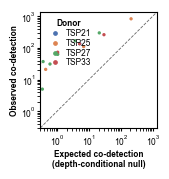

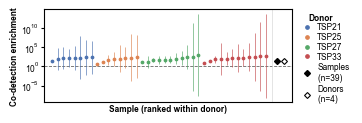

wrote:
  /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks/figures/06_44b_fig5_codetection_observed_vs_expected.pdf
  /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks/figures/suppfigure11/06_44b_fig5_codetection_forest.pdf

NOTE: figures/06_44b_fig5_codetection.pdf (the old combined panel) is now
stale on disk. It is no longer written by this notebook.


In [8]:
# --- Fig. 5 co-detection, as TWO standalone panels --------------------------
# Split from a single two-panel figure so the pieces can be placed
# independently: the forest carries the quotable estimate and is the main-text
# candidate, while observed-vs-expected is a supplement panel. Each is now a
# complete figure with its own donor legend, so neither depends on the other
# being adjacent on the page.
donors = sorted(ok_t['donor'].unique())
cmap = {d: DONOR_PALETTE[i % len(DONOR_PALETTE)] for i, d in enumerate(donors)}


def _donor_handles():
    return [plt.Line2D([], [], color=cmap[d], marker='o', ls='', ms=2.4, label=d)
            for d in donors]


# --- Panel 1: observed vs expected, one point per sample --------------------
fig, ax = plt.subplots(figsize=(1.5, 1.5))
lim = [max(0.3, ok_t.expected.min() * 0.6), ok_t.observed.max() * 1.6]
ax.plot(lim, lim, ls='--', lw=0.6, color='0.4', zorder=1)
for d in donors:
    s = ok_t[ok_t.donor == d]
    ax.scatter(s.expected, s.observed, s=2.4 ** 2, color=cmap[d],
               zorder=2,
               edgecolors='none')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Expected co-detection\n(depth-conditional null)')
ax.set_ylabel('Observed co-detection')
# ax.set_title('Per sample', pad=PANEL_TITLE_PAD)
leg = ax.legend(handles=_donor_handles(), frameon=False, title='Donor',
                loc='upper left', handletextpad=0.2)
leg.get_title().set_fontweight('bold')
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_07_fig5_codetection_observed_vs_expected.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

# --- Panel 2: per-sample forest, TRANSPOSED ---------------------------------
# Samples run along x, enrichment on y. figsize is the inverse of the vertical
# version: a vertical forest wants a wide, short panel the same way the
# horizontal one wanted a narrow, tall one.
fig, ax = plt.subplots(figsize=(3.2, 1.2))
d_ok = ok_t.sort_values(['donor', 'enrichment']).reset_index(drop=True)
for i, r in d_ok.iterrows():
    lo = np.exp(np.log(r['enrichment']) - 1.96 * r['se'])
    hi = np.exp(np.log(r['enrichment']) + 1.96 * r['se'])
    ax.errorbar(i, r['enrichment'],
                yerr=[[r['enrichment'] - lo], [hi - r['enrichment']]],
                fmt='o', ms=1.7, lw=0.45, color=cmap[r['donor']], zorder=2)
ax.axhline(1, color='0.4', lw=0.6, ls='--', zorder=1)
x_t, x_d = len(d_ok) + 1.0, len(d_ok) + 2.3
# light rule separating the samples from the two summaries
ax.axvline(len(d_ok) + 0.1, color='0.85', lw=0.5, zorder=1)
# Pooled summaries in BLACK, filled (samples) vs open (donors). Black plus a fill
# distinction cannot collide however many donors appear, and it survives greyscale
# printing.
ax.errorbar([x_t], [np.exp(flat['effect'])],
            yerr=[[np.exp(flat['effect']) - np.exp(flat['ci_low'])],
                  [np.exp(flat['ci_high']) - np.exp(flat['effect'])]],
            fmt='D', ms=3.0, lw=1.0, color='k', ecolor='k', zorder=4)
ax.errorbar([x_d], [np.exp(nested['effect'])],
            yerr=[[np.exp(nested['effect']) - np.exp(nested['ci_low'])],
                  [np.exp(nested['ci_high']) - np.exp(nested['effect'])]],
            fmt='D', ms=3.0, lw=1.0, color='k', ecolor='k',
            markerfacecolor='white', markeredgewidth=0.8, zorder=4)
# Heterogeneity, stated on the panel: I2 = 56% is moderate, and it is why the
# pooling uses the Knapp-Hartung correction rather than a plain DL z.
# The character is literal Unicode superscript two, not mathtext, so it cannot
# fall back to DejaVu mid-figure.
# ax.annotate('I\u00b2 = ' + format(flat['I2'], '.0f') + '%',
#             xy=(0.02, 0.98), xycoords='axes fraction', ha='left', va='top',
#             fontsize=6, color='0.35')
ax.set_yscale('log')
# No x ticks: the axis is an arbitrary ranking of samples. set_xticklabels([])
# would blank the text but LEAVE THE TICK MARKS drawn and desynchronise the
# formatter from the locator; set_xticks([]) removes all three together.
ax.set_xticks([])
ax.set_xlim(-1.5, x_d + 1.3)
ax.set_ylabel('Co-detection enrichment')
ax.set_xlabel('Sample (ranked within donor)')
# ax.set_title('Effect by sample', pad=PANEL_TITLE_PAD)

# Donor legend stays inside; it explains the sample points only.
leg = ax.legend(handles=_donor_handles(), frameon=False, title='Donor',
                loc=6, handletextpad=0.2, bbox_to_anchor = (1,0.7))
leg.get_title().set_fontweight('bold')
ax.add_artist(leg)      # a second ax.legend() would otherwise REPLACE this one

# The pooled estimates have no axis label of their own, so they go in a legend
# below the axes and carry their values with them. bbox_inches='tight' grows
# the canvas at save time so nothing is clipped. Marker styling is copied from
# the errorbar calls above so each key matches its glyph -- filled = samples,
# open = donors.
pooled_h = [
    plt.Line2D([], [], color='k', marker='D', ls='', ms=3.0,
               label='Samples\n(n=' + str(len(d_ok)) + ') '),
                     # + format(np.exp(flat['effect']), '.2f') + ' ['
                     # + format(np.exp(flat['ci_low']), '.2f') + ', '
                     # + format(np.exp(flat['ci_high']), '.2f') + ']'),
    plt.Line2D([], [], color='k', marker='D', ls='', ms=3.0,
               markerfacecolor='white', markeredgewidth=0.8,
               label='Donors\n(n=' + str(nested['k']) + ') '),
                     # + format(np.exp(nested['effect']), '.2f') + ' ['
                     # + format(np.exp(nested['ci_low']), '.2f') + ', '
                     # + format(np.exp(nested['ci_high']), '.2f') + ']'),
]
ax.legend(handles=pooled_h, frameon=False, loc=6,
          bbox_to_anchor=(1.0, 0.2), ncol=1, handletextpad=0.3,
          labelspacing=0.25)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_07_fig5_codetection_forest.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

print('wrote:')
print('  ' + figpath('06_07_fig5_codetection_observed_vs_expected.pdf'))
print('  ' + figpath('06_07_fig5_codetection_forest.pdf'))
print()
print('NOTE: figures/06_07_fig5_codetection.pdf (the old combined panel) is now')
print('stale on disk. It is no longer written by this notebook.')


## 6. Supplementary panels


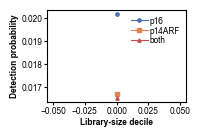

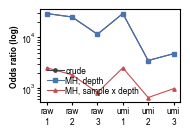

In [8]:
# --- Supp A: the capture mechanism, as TWO standalone figures ---------------
# Split so each panel can be placed independently. With the titles removed the
# filenames are now what distinguishes them.

# A1: detection probability against capture depth
fig, ax = plt.subplots(figsize=(1.8, 1.20))
ax.plot(depth_tab.depth_decile, depth_tab.P_p16, 'o-', ms=2.4, lw=0.8,
        color=P16_COLOR, label='p16')
ax.plot(depth_tab.depth_decile, depth_tab.P_p14ARF, 's-', ms=2.4, lw=0.8,
        color=P14_COLOR, label='p14ARF')
ax.plot(depth_tab.depth_decile, depth_tab.P_both, '^-', ms=2.4, lw=0.8,
        color=BOTH_COLOR, label='both')
ax.set_xlabel('Library-size decile')
ax.set_ylabel('Detection probability')
# ax.set_title('Detection rises with capture depth', pad=PANEL_TITLE_PAD)
ax.legend(frameon=False, handletextpad=0.2)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_07_supp_detection_vs_depth.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

# A2: the odds ratio under three stratifications and three thresholds
fig, ax = plt.subplots(figsize=(1.8, 1.20))
xp = np.arange(len(or_tab))
ax.plot(xp, or_tab.crude_OR, 'o-', ms=2.4, lw=0.8, color='0.25', label='crude')
ax.plot(xp, or_tab.MH_wholecell, 's-', ms=2.4, lw=0.8, color=P16_COLOR,
        label='MH, depth')
ax.plot(xp, or_tab.MH_tube_x_depth, '^-', ms=2.4, lw=0.8, color=BOTH_COLOR,
        label='MH, sample x depth')
ax.set_yscale('log')
ax.set_xticks(xp)
ax.set_xticklabels([r.flavour + '\n' + str(r.threshold) for r in or_tab.itertuples()])
ax.set_ylabel('Odds ratio (log)')
# ax.set_title('OR is threshold- and\nstratification-dependent', pad=PANEL_TITLE_PAD)
ax.legend(frameon=False, handletextpad=0.2)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_07_supp_or_threshold_stratification.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()


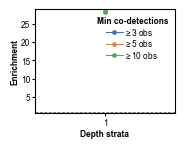

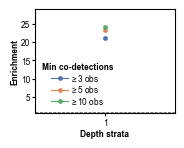

Supp B split -> sensitivity_samples.pdf, sensitivity_donors.pdf
common y range pinned to 0.63-29.00 so the two remain comparable


In [9]:
# --- Supp B: parameter sensitivity, as TWO standalone figures ---------------
# These previously shared a y axis (sharey=True), which is what let the reader
# compare the sample-level and donor-level enrichments directly. Splitting the
# figure destroys that unless the range is pinned, so a COMMON ylim is computed
# across both series and applied to each -- otherwise matplotlib autoscales them
# independently and the two panels silently stop being comparable.
_y = np.concatenate([sens['sample_enrichment'].values,
                     sens['donor_enrichment'].values])
_y = _y[np.isfinite(_y)]
_pad = 0.05 * (_y.max() - _y.min())
YLIM = (min(_y.min(), 1.0) - _pad, max(_y.max(), 1.0) + _pad)

for col, lab, fname in [('sample_enrichment', 'Samples',
                         '06_07_supp_sensitivity_samples.pdf'),
                        ('donor_enrichment', 'Donors',
                         '06_07_supp_sensitivity_donors.pdf')]:
    fig, ax = plt.subplots(figsize=(1.8, 1.35))
    for j, mo in enumerate(sorted(sens.min_observed.unique())):
        s = sens[sens.min_observed == mo]
        ax.plot(s.n_bins, s[col], 'o-', lw=0.8, ms=2.4, color=DONOR_PALETTE[j],
                label='$\\geq$' + str(mo) + ' obs')
    ax.axhline(1, color='0.4', lw=0.6, ls='--')
    ax.set_xlabel('Depth strata')
    ax.set_xticks(sorted(sens.n_bins.unique()))
    ax.set_ylim(YLIM)
    ax.set_ylabel('Enrichment')
    # ax.set_title(lab, pad=PANEL_TITLE_PAD)
    leg = ax.legend(frameon=False, title='Min co-detections',
                    handletextpad=0.2)
    leg.get_title().set_fontweight('bold')
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    fig.savefig(figpath(fname), bbox_inches='tight', dpi=300)
    plt.show()

print('Supp B split -> sensitivity_samples.pdf, sensitivity_donors.pdf')
print('common y range pinned to ' + format(YLIM[0], '.2f') + '-'
      + format(YLIM[1], '.2f') + ' so the two remain comparable')


  capping at 50,000 of 155,117 cells (dense bool would be 7.6 GB)
{'n_pairs': 500, 'median_or': 1.5480966442696296, 'p95_or': 9.626755780752056, 'p99_or': 56.96389494548795, 'max_or': 227.78643538250378}


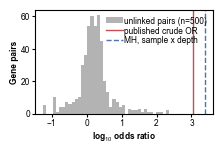

In [10]:
# --- Supp C: matched unlinked gene-pair null (the reviewer's own control) ----
# How large an OR do two INDEPENDENT genes at the same detection rate produce
# from capture variation alone? Loads the gene matrix; skip if unavailable.
try:
    import scanpy as sc
    from scipy.sparse import issparse
    ad = sc.read_h5ad(GENES)
    ad = ad[ad.obs_names.isin(obs.index[measured])].copy()
    # matched_pair_or_null needs a DENSE cells x genes boolean. At the full
    # atlas that is ~7.6 GB, so the cell set is capped here. The null is a
    # distribution over gene PAIRS, not over cells, so a large random subsample
    # changes its width only marginally -- but the cap is stated because it is
    # a real limit on the panel, not a free choice.
    if ad.n_obs > MATCHED_PAIR_MAX_CELLS:
        print(f'  capping at {MATCHED_PAIR_MAX_CELLS:,} of {ad.n_obs:,} cells '
              f'(dense bool would be '
              f'{ad.n_obs * ad.n_vars / 1e9:.1f} GB)')
        _rs = np.random.default_rng(0).choice(ad.n_obs, MATCHED_PAIR_MAX_CELLS,
                                              replace=False)
        ad = ad[np.sort(_rs)].copy()
    gname = (ad.var['gene_name'].astype(str) if 'gene_name' in ad.var.columns
             else pd.Series(ad.var_names, index=ad.var_names).astype(str))
    ad = ad[:, ~(gname.str.startswith('CDKN2A') | gname.str.startswith('CDKN2B')).values].copy()
    D = ad.X > 0
    D = D.toarray() if issparse(D) else np.asarray(D)
    r16, r14 = float(x.mean()), float(y.mean())
    null_pairs = sr.matched_pair_or_null(D, (r16, r14), n_pairs=500, tol=0.1, seed=0)
    print({k: v for k, v in null_pairs.items() if k != 'ors'})
    if null_pairs.get('n_pairs', 0) > 0:
        ors = null_pairs['ors']
        fig, ax = plt.subplots(figsize=(2.3, 1.35))
        ax.hist(np.log10(ors[ors > 0]), bins=40, color='0.7', edgecolor='none',
                label='unlinked pairs (n=' + str(null_pairs['n_pairs']) + ')')
        ax.axvline(np.log10(final['published_crude_or']), color=BOTH_COLOR, lw=1.0,
                   label='published crude OR')
        ax.axvline(np.log10(final['mh_tube_x_depth']), color=P16_COLOR, lw=1.0, ls='--',
                   label='MH, sample x depth')
        ax.set_xlabel('log$_{10}$ odds ratio'); ax.set_ylabel('Gene pairs')
        # ax.set_title('Matched unlinked gene-pair null', pad=PANEL_TITLE_PAD)
        ax.legend(frameon=False, handletextpad=0.2); ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
        fig.savefig(figpath('06_07_supp_matched_gene_pair_null.pdf'),
                    bbox_inches='tight', dpi=300)
        plt.show()
        pd.DataFrame({'or': ors}).to_csv(OUT + '/06_07_final_matched_pair_ors.csv',
                                         index=False)
        final['matched_pair_median_or'] = null_pairs['median_or']
        final['matched_pair_p99_or'] = null_pairs['p99_or']
    del ad, D
except Exception as e:
    print('SKIPPED matched gene-pair null:', type(e).__name__, e)
    print('CAVEAT if reported: those pairs come from the whole-cell assay while')
    print('p16/p14ARF come from the targeted pulldown, so it bounds the OR that')
    print('capture variation can manufacture -- it is not a like-for-like null.')

## 7. Numbers and text for the manuscript


In [ ]:
pd.Series(final).to_csv(OUT + '/06_07_final_numbers.csv', header=['value'])
